In [40]:
import os

# Original file name
original_file = "netflix_data.csv"  
# Replace with new file name
new_file_name = "Netflix_shows_movies.csv"

# Rename the file
os.rename(original_file, new_file_name)

# Load into a DataFrame
import pandas as pd
df = pd.read_csv(new_file_name)

# Preview the data
print(df.head())


    show_id     type                                    title  \
0  81145628    Movie  Norm of the North: King Sized Adventure   
1  80117401    Movie               Jandino: Whatever it Takes   
2  70234439  TV Show                       Transformers Prime   
3  80058654  TV Show         Transformers: Robots in Disguise   
4  80125979    Movie                             #realityhigh   

                   director  \
0  Richard Finn, Tim Maltby   
1                       NaN   
2                       NaN   
3                       NaN   
4          Fernando Lebrija   

                                                cast  \
0  Alan Marriott, Andrew Toth, Brian Dobson, Cole...   
1                                   Jandino Asporaat   
2  Peter Cullen, Sumalee Montano, Frank Welker, J...   
3  Will Friedle, Darren Criss, Constance Zimmer, ...   
4  Nesta Cooper, Kate Walsh, John Michael Higgins...   

                                    country         date_added  release_year  \
0  Un

In [41]:
import pandas as pd

# Load data
df = pd.read_csv('Netflix_shows_movies.csv')

# Convert 'date_added' to datetime and handle missing values
df['date_added'] = pd.to_datetime(df['date_added'], errors='coerce')
df.fillna({'director': 'Unknown', 'cast': 'Unknown', 'country': 'Unknown'}, inplace=True)

# Split 'duration' into 'duration_value' and 'duration_type'
df[['duration_value', 'duration_type']] = df['duration'].str.extract(r'(\d+)\s+(\w+)')
df['duration_value'] = pd.to_numeric(df['duration_value'], errors='coerce')


In [42]:
# Extract year_added
df['year_added'] = df['date_added'].dt.year

# Extract main country
df['main_country'] = df['country'].apply(lambda x: x.split(',')[0] if pd.notnull(x) else 'Unknown')


In [43]:
print("Type Distribution:\n", df['type'].value_counts())


Type Distribution:
 type
Movie      4265
TV Show    1969
Name: count, dtype: int64


In [44]:
df.reset_index(drop=True, inplace=True)  # Reset to start at 0
df.index += 1  # Shift to start from 1

In [45]:
import pandas as pd

df = pd.read_csv('Netflix_shows_movies.csv')

# Check for duplicates in the 'title' column
duplicate_titles = df[df.duplicated('title', keep=False)]

# Display the duplicate titles along with any relevant columns, like 'release_year' and 'type'
print("Duplicate Titles:\n", duplicate_titles[['title', 'release_year', 'type']].sort_values('title'))

# Count the number of unique and duplicate titles
total_titles = df['title'].nunique()
duplicate_count = len(duplicate_titles['title'].unique())
print(f"\nTotal Unique Titles: {total_titles}")
print(f"Number of Duplicate Titles: {duplicate_count}")


Duplicate Titles:
                         title  release_year     type
5905                 Aquarius          2016  TV Show
3441                 Aquarius          2016    Movie
2159                    Benji          2018    Movie
1969                    Benji          1974    Movie
5724                   Bleach          2006  TV Show
...                       ...           ...      ...
2320  Wet Hot American Summer          2001    Movie
3131                      Zoo          2018    Movie
5656                      Zoo          2017  TV Show
3456                     Zoom          2006    Movie
4567                     Zoom          2015    Movie

[119 rows x 3 columns]

Total Unique Titles: 6172
Number of Duplicate Titles: 57


In [46]:
import pandas as pd

df = pd.read_csv('Netflix_shows_movies.csv')
top_directors = df['director'].value_counts().head(10)
print("Top 10 Directors:\n", top_directors)

Top 10 Directors:
 director
Raúl Campos, Jan Suter    18
Marcus Raboy              14
Jay Karas                 13
Jay Chapman               12
Steven Spielberg           9
Martin Scorsese            9
Lance Bangs                8
Johnnie To                 8
David Dhawan               8
Hakan Algül                7
Name: count, dtype: int64


In [47]:
import pandas as pd

df = pd.read_csv('Netflix_shows_movies.csv')
top_cast = df['cast'].str.split(', ').explode().value_counts().head(10)
print("Top 10 Actors:\n", top_cast)


Top 10 Actors:
 cast
Anupam Kher         33
Shah Rukh Khan      30
Om Puri             27
Naseeruddin Shah    27
Akshay Kumar        26
Yuki Kaji           26
Takahiro Sakurai    25
Paresh Rawal        25
Amitabh Bachchan    24
Boman Irani         23
Name: count, dtype: int64


In [48]:
import pandas as pd

df = pd.read_csv('Netflix_shows_movies.csv')
top_countries = df['country'].value_counts().head(10)
print("Top 10 Countries:\n", top_countries)


Top 10 Countries:
 country
United States     2032
India              777
United Kingdom     348
Japan              176
Canada             141
South Korea        136
Spain              117
France              90
Mexico              83
Turkey              79
Name: count, dtype: int64


In [ ]:
import pandas as pd

df = pd.read_csv('Netflix_shows_movies.csv')
titles_added_over_ime = df['date_added'].value_counts().sort_index()
print("Titles Added Over Time:\n", df['date_added'].value_counts().sort_index())


Titles Added Over Time:
 date_added
 April 1, 2014        1
 April 1, 2016        2
 April 1, 2019        1
 April 10, 2019       1
 April 11, 2019       1
                     ..
September 8, 2015     1
September 8, 2017    21
September 8, 2018     2
September 9, 2016     1
September 9, 2019     1
Name: count, Length: 1524, dtype: int64


In [ ]:
import pandas as pd

df = pd.read_csv('Netflix_shows_movies.csv')
print("Titles Released by Year:\n", df['release_year'].value_counts().sort_index())

Titles Released by Year:
 release_year
1925       1
1942       2
1943       3
1944       3
1945       3
        ... 
2016     830
2017     959
2018    1063
2019     843
2020      25
Name: count, Length: 72, dtype: int64


In [ ]:

print("Rating Distribution:\n", df['rating'].value_counts())


Rating Distribution:
 rating
TV-MA       2027
TV-14       1698
TV-PG        701
R            508
PG-13        286
NR           218
PG           184
TV-Y7        169
TV-G         149
TV-Y         143
TV-Y7-FV      95
G             37
UR             7
NC-17          2
Name: count, dtype: int64


In [9]:
import pandas as pd

df = pd.read_csv('Netflix_shows_movies.csv')

df[df['type'] == 'Movie']['duration'].describe()

df[df['type'] == 'TV Show']['duration'].value_counts()

print("Movie Durations:\n", df[df['type'] == 'Movie']['duration'].describe())
print("TV Show Seasons:\n", df[df['type'] == 'TV Show']['duration'].value_counts())


Movie Durations:
 count       4265
unique       186
top       90 min
freq         111
Name: duration, dtype: object
TV Show Seasons:
 duration
1 Season      1321
2 Seasons      304
3 Seasons      158
4 Seasons       61
5 Seasons       46
6 Seasons       22
7 Seasons       21
8 Seasons       16
9 Seasons        7
10 Seasons       3
11 Seasons       3
15 Seasons       2
12 Seasons       2
13 Seasons       2
14 Seasons       1
Name: count, dtype: int64


In [10]:
genres = df['listed_in'].str.split(', ').explode().value_counts().head(10)
print("Top 10 Genres:\n", genres)


Top 10 Genres:
 listed_in
International Movies      1927
Dramas                    1623
Comedies                  1113
International TV Shows    1001
Documentaries              668
TV Dramas                  599
Action & Adventure         597
Independent Movies         552
TV Comedies                436
Thrillers                  392
Name: count, dtype: int64


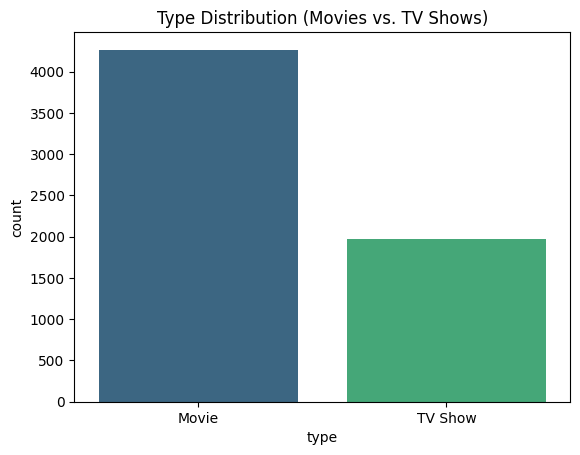

In [11]:
# Bar chart of type distribution (Movies vs. TV Shows)

import matplotlib.pyplot as plt
import seaborn as sns
sns.countplot(data=df, x='type', hue='type', palette='viridis', legend=False)
plt.title('Type Distribution (Movies vs. TV Shows)')
plt.show()


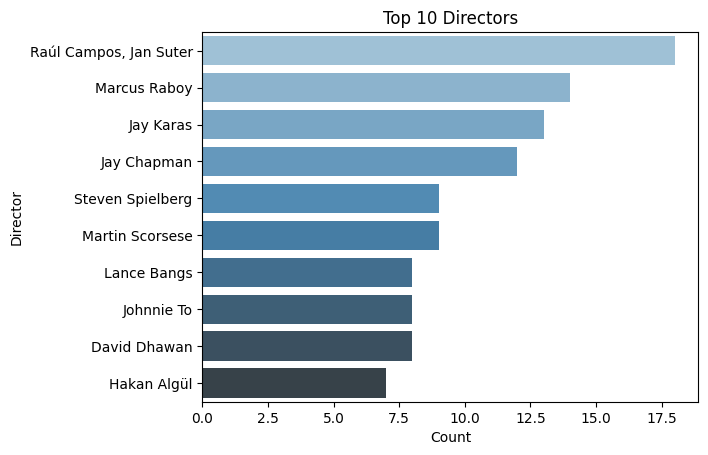

In [12]:
# Horizontal bar chart for frequency for top 10 directors

import matplotlib.pyplot as plt
import seaborn as sns
top_directors = df['director'].value_counts().head(10)
sns.barplot(x=top_directors.values, y=top_directors.index, hue=top_directors.index, palette="Blues_d", legend=False)
plt.title('Top 10 Directors')
plt.xlabel('Count')
plt.ylabel('Director')
plt.show()


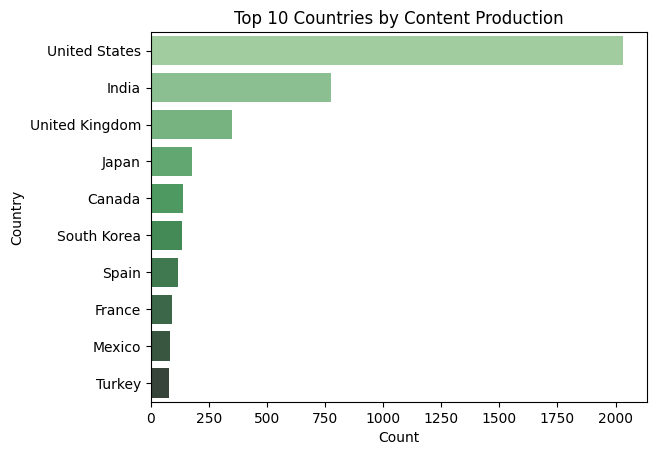

In [13]:
# Horizontal bar chart for production top 10 countries

import matplotlib.pyplot as plt
import seaborn as sns
top_countries = df['country'].value_counts().head(10)
sns.barplot(x=top_countries.values, y=top_countries.index, hue=top_countries.index, palette="Greens_d", legend=False)
plt.title('Top 10 Countries by Content Production')
plt.xlabel('Count')
plt.ylabel('Country')
plt.show()


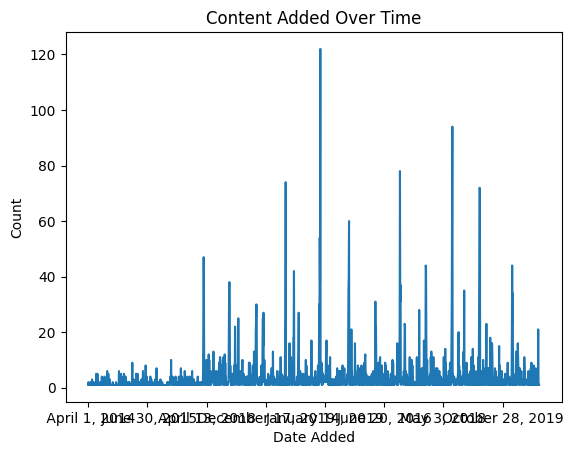

In [14]:
# Content Added Over Time (Line plot of content added each date)

import matplotlib.pyplot as plt
import seaborn as sns
titles_added_over_ime = df['date_added'].value_counts().sort_index()
df['date_added'].value_counts().sort_index().plot(kind='line')
plt.title('Content Added Over Time')
plt.xlabel('Date Added')
plt.ylabel('Count')
plt.show()



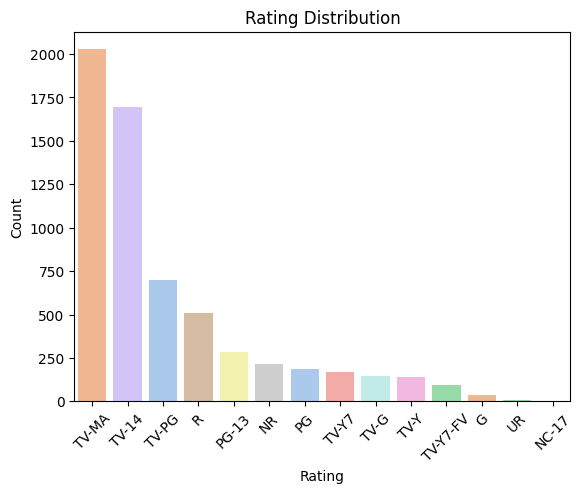

In [15]:
# Rating Distribution (Bar chart for content ratings)

import matplotlib.pyplot as plt
import seaborn as sns
order = df['rating'].value_counts()
sns.countplot(data=df, x='rating', hue='rating', palette='pastel', order=df['rating'].value_counts().index, legend=False)
plt.title('Rating Distribution')
plt.xlabel('Rating')
plt.ylabel('Count')
plt.xticks(rotation=45)
plt.show()


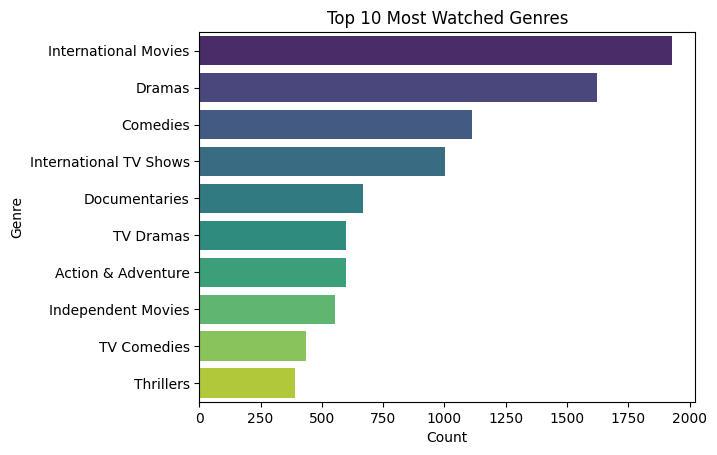

In [17]:
# Horizontal bar chart for frequency of genres

import matplotlib.pyplot as plt
import seaborn as sns
genres = df['listed_in'].str.split(', ').explode().value_counts().head(10)
sns.barplot(x=genres.values, y=genres.index, hue=genres.index, palette='viridis', legend=False)
plt.title('Top 10 Most Watched Genres')
plt.xlabel('Count')
plt.ylabel('Genre')
plt.show()
